# Demo experiment, May 4, Francesco Braicovich

**Trait:** politeness  
**Model:** `google/gemma-2-2b` (base, completion)  
**Layer:** 13, central (there are 26 layers in total)  
**Data:** accepted paraphrases from the smoke-test run (`output/politeness/accepted.jsonl`)

Unlike Bettineschi's notebook (which used hand-written single-sentence prompts), this notebook
loads the LLM-generated ordinal paraphrases produced by the data generation pipeline and checks
whether the low → mid → high politeness ladder leaves a linear trace in activation space.

In [ ]:
import json
import sys
from pathlib import Path

import torch

sys.path.insert(0, str(Path("..").resolve()))  # src/notebooks/ -> src/

from lib.data_typing import Sample, LEVELS, load_accepted
from lib.representations import load_model, extract_activations, extract_activations_multilayer
from lib.analysis import compute_difference_vectors, similarity_matrix, plot_similarity_matrix

In [ ]:
MODEL   = "google/gemma-2-2b"
LAYER   = 13
TRAIT   = "politeness"
ACCEPTED_JSONL = Path("../../data/v1_smoke_large/politeness/accepted.jsonl")

In [ ]:
records_raw = []
with ACCEPTED_JSONL.open() as f:
    for line in f:
        line = line.strip()
        if line:
            records_raw.append(json.loads(line))

found = {r["level"] for r in records_raw}
levels_present = [l for l in LEVELS if l in found]
print(f"Loaded {len(records_raw)} accepted paraphrases")
print(f"Levels found (ordered): {levels_present}")
for lvl in levels_present:
    texts = [r["text"] for r in records_raw if r["level"] == lvl]
    print(f"  {lvl}: {len(texts)} items — e.g. '{texts[0][:80]}'")

Loaded 54 accepted paraphrases
Levels found (ordered): ['low', 'mid', 'high']
  low: 16 items — e.g. 'The data analysis section must include a more rigorous statistical justification'
  mid: 19 items — e.g. 'It would strengthen the manuscript if the data analysis section offered a more r'
  high: 19 items — e.g. 'I commend the thorough work presented; nevertheless, the data analysis section w'


In [ ]:
samples = load_accepted(ACCEPTED_JSONL)
TRAITS_CFG = [{"name": TRAIT, "intensities": levels_present}]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"device: {device}")

device: mps


In [ ]:
# slow — run once
model, tokenizer = load_model(MODEL, device)

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

In [ ]:
activations = extract_activations(samples, model, tokenizer, LAYER, device)

for (trait, intensity, scenario_id), vec in activations.items():
    print(f"  ({trait}, {intensity}, {scenario_id}): shape={vec.shape}, norm={vec.norm():.2f}")

  (politeness, low, politeness-criticism-or-feedback-001): shape=torch.Size([2304]), norm=137.02
  (politeness, mid, politeness-criticism-or-feedback-001): shape=torch.Size([2304]), norm=141.81
  (politeness, high, politeness-criticism-or-feedback-001): shape=torch.Size([2304]), norm=146.47
  (politeness, low, politeness-criticism-or-feedback-003): shape=torch.Size([2304]), norm=142.12
  (politeness, mid, politeness-criticism-or-feedback-003): shape=torch.Size([2304]), norm=141.65
  (politeness, high, politeness-criticism-or-feedback-003): shape=torch.Size([2304]), norm=146.58
  (politeness, low, politeness-disagreement-013): shape=torch.Size([2304]), norm=153.69
  (politeness, mid, politeness-disagreement-013): shape=torch.Size([2304]), norm=138.31
  (politeness, high, politeness-disagreement-013): shape=torch.Size([2304]), norm=153.77
  (politeness, low, politeness-refusal-032): shape=torch.Size([2304]), norm=133.25
  (politeness, mid, politeness-refusal-032): shape=torch.Size([2304]

In [ ]:
diffs = compute_difference_vectors(activations, TRAITS_CFG)

for (trait, lo, hi), vec in diffs.items():
    print(f"  {trait}: {lo} -> {hi}  norm={vec.norm():.2f}")

  politeness: mid -> high  norm=17.87
  politeness: low -> mid  norm=18.94
  politeness: low -> high  norm=24.67


In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

labels, matrix = similarity_matrix(diffs)

print("Cosine similarity matrix:")
header = f"{'':>25}" + "".join(f"{l:>27}" for l in labels)
print(header)
for i, li in enumerate(labels):
    row = f"{li:>25}" + "".join(f"{matrix[i, j]:>27.4f}" for j in range(len(labels)))
    print(row)

if len(labels) >= 2:
    print(f"\nKey number — cosine similarity {labels[0]} vs {labels[1]}: {matrix[0, 1]:.4f}")
    print("  +1 = same direction (linear), -1 = opposite, ~0 = unrelated")

Cosine similarity matrix:
                                 politeness:high-mid         politeness:mid-low        politeness:high-low
      politeness:high-mid                     1.0000                    -0.1488                     0.6571
       politeness:mid-low                    -0.1488                     1.0000                     0.6317
      politeness:high-low                     0.6571                     0.6317                     1.0000

Key number — cosine similarity politeness:high-mid vs politeness:mid-low: -0.1488
  +1 = same direction (linear), -1 = opposite, ~0 = unrelated


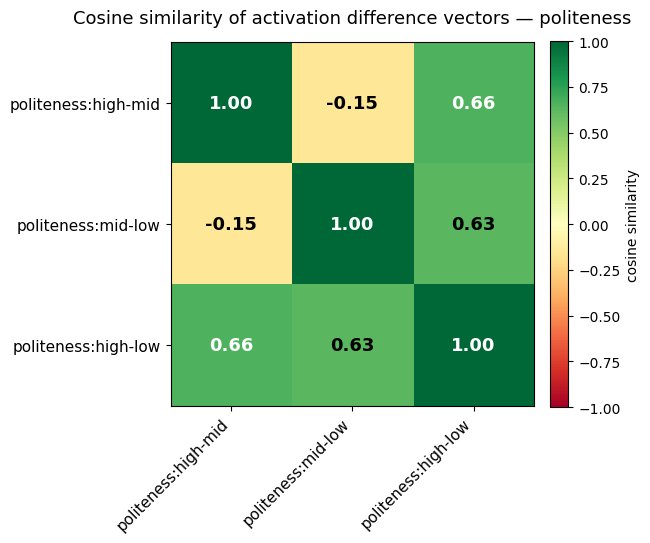

In [ ]:
n = len(labels)
cell = 2.2
fig, ax = plt.subplots(figsize=(max(6, n * cell), max(6, n * cell)))
im = ax.imshow(matrix, vmin=-1, vmax=1, cmap="RdYlGn")
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
for i, j in itertools.product(range(n), range(n)):
    color = "white" if abs(matrix[i, j]) > 0.65 else "black"
    ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
            fontsize=13, fontweight="bold", color=color)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("cosine similarity", fontsize=10)
ax.set_title(f"Cosine similarity of activation difference vectors — {TRAIT}", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

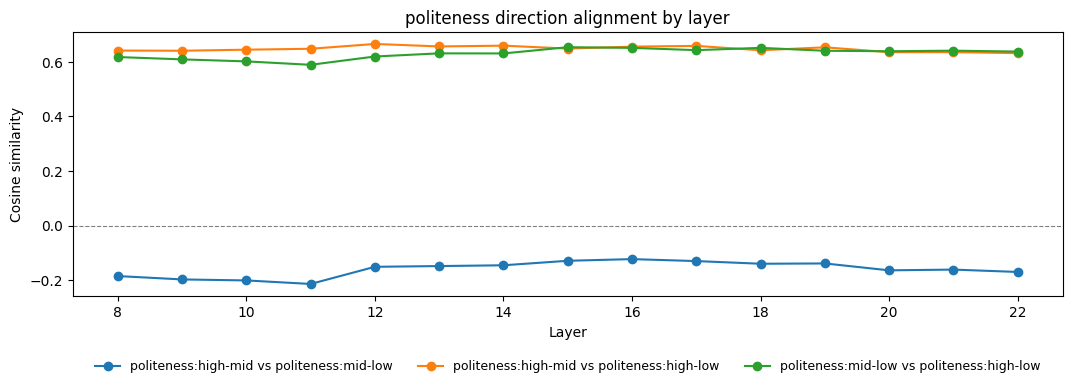

In [ ]:
sweep_layers = list(range(8, 23))

# One forward pass per batch, all layers captured at once.
acts_all = extract_activations_multilayer(samples, model, tokenizer, sweep_layers, device)

pair_indices = list(itertools.combinations(range(len(labels)), 2))
pair_sims = {pair: [] for pair in pair_indices}

for layer in sweep_layers:
    acts_layer = {(t, i, s): v for (t, i, s, l), v in acts_all.items() if l == layer}
    d = compute_difference_vectors(acts_layer, TRAITS_CFG)
    _, m = similarity_matrix(d)
    for pair in pair_indices:
        pair_sims[pair].append(m[pair[0], pair[1]])

fig, ax = plt.subplots(figsize=(11, 4.4))
for (i, j), sims in pair_sims.items():
    ax.plot(sweep_layers, sims, marker="o", linewidth=1.5, label=f"{labels[i]} vs {labels[j]}")

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title(f"{TRAIT} direction alignment by layer")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=9)
fig.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.28)
plt.show()

## Random Wikipedia baseline

Fetch random Wikipedia summaries, pair them randomly, and compute a null distribution
of cosine similarities between difference vectors of random text pairs. This tells us
what cosines to expect when there is no underlying trait signal — the politeness
cosines must sit far outside this distribution to be meaningful.

In [ ]:
#import random as _random
#from sklearn.datasets import fetch_20newsgroups
#
#WIKI_N = 60          # random text snippets to use as a null baseline
#WIKI_PAIRS = 200     # null cosine samples
#WIKI_SEED = 7
#
## 20 Newsgroups is sklearn-native (already a dep), ~14MB, cached after first call.
## We strip headers/footers/quotes so what's left is plain prose.
#_ds = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
#_rng = _random.Random(WIKI_SEED)
#_candidates = [t.strip().replace('\n', ' ') for t in _ds.data
#               if t and 20 <= len(t.split()) <= 200]
#_rng.shuffle(_candidates)
#wiki_texts = _candidates[:WIKI_N]
#print(f'fetched {len(wiki_texts)} text snippets')
#print('example:', wiki_texts[0][:140])

In [ ]:
#wiki_samples = [
#    Sample(prompt=t, trait='wiki', intensity='rand', scenario_id=f'wiki-{i:03d}')
#    for i, t in enumerate(wiki_texts)
#]
#wiki_acts_dict = extract_activations(wiki_samples, model, tokenizer, LAYER, device)
#wiki_vecs = [wiki_acts_dict[('wiki', 'rand', f'wiki-{i:03d}')] for i in range(len(wiki_texts))]
#print(f'wiki activations: n={len(wiki_vecs)}, dim={tuple(wiki_vecs[0].shape)}')

In [ ]:
#from scipy.spatial.distance import cosine as _cos
#
#rng = _random.Random(WIKI_SEED)
#null_cosines = []
#for _ in range(WIKI_PAIRS):
#    a, b, c, d = rng.sample(range(len(wiki_vecs)), 4)
#    diff1 = (wiki_vecs[a] - wiki_vecs[b]).numpy()
#    diff2 = (wiki_vecs[c] - wiki_vecs[d]).numpy()
#    null_cosines.append(1.0 - _cos(diff1, diff2))
#
#null_arr = np.array(null_cosines)
#print(f'null cosine distribution (n={len(null_arr)}):')
#print(f'  mean={null_arr.mean():.4f}  std={null_arr.std():.4f}')
#print(f'  q05={np.quantile(null_arr, 0.05):.4f}  q95={np.quantile(null_arr, 0.95):.4f}  q99={np.quantile(null_arr, 0.99):.4f}')
#
#print('\nPoliteness off-diagonal cosines vs null:')
#for i in range(len(labels)):
#    for j in range(i + 1, len(labels)):
#        v = matrix[i, j]
#        p_emp = float((null_arr >= v).mean())
#        print(f'  {labels[i]:>22} vs {labels[j]:<22} cos={v:+.4f}  p(null>=obs)={p_emp:.4f}')

In [ ]:
#fig, ax = plt.subplots(figsize=(9, 4.4))
#ax.hist(null_arr, bins=40, color='lightgray', edgecolor='gray', label='Wikipedia null pairs')
#_colors = plt.cm.tab10(np.linspace(0, 1, 10))
#_k = 0
#for i in range(len(labels)):
#    for j in range(i + 1, len(labels)):
#        ax.axvline(matrix[i, j], color=_colors[_k % 10], linewidth=2,
#                   label=f'{labels[i]} vs {labels[j]}: {matrix[i, j]:+.2f}')
#        _k += 1
#ax.axvline(0, color='black', linewidth=0.7, linestyle=':')
#ax.set_xlabel('cosine similarity of difference vectors')
#ax.set_ylabel('count (null pairs)')
#ax.set_title(f'Politeness vs random-Wikipedia null distribution — layer {LAYER}')
#ax.legend(fontsize=8, loc='upper left')
#plt.tight_layout()
#plt.show()

## Ordinal linearity metrics

Four standard tests that exploit the ordinal `low → mid → high` rank. All operate on
the same per-sample activations:

- **Spearman ρ / Kendall τ** of the per-sample projection onto the trait direction
  `μ_high − μ_low` vs. the true rank. Tests monotonicity; does not assume equal spacing.
- **Linear probe R²** — ridge regression predicting rank from the activation, 5-fold CV.
  Tests whether rank is linearly decodable.
- **Centroid midpoint residual** — `‖μ_mid − (μ_low + μ_high)/2‖ / ‖μ_high − μ_low‖`.
  Zero iff the three centroids are collinear and equally spaced.
- **PC1 variance fraction** of the K class centroids. One iff centroids are collinear
  (allows unequal spacing).

Each is reported at layer 13 with a label-permutation null, then swept across layers.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import spearmanr, kendalltau


def _per_level_arrays(acts_by_level, levels_ordered):
    X = np.stack([v.numpy() for lvl in levels_ordered for v in acts_by_level[lvl]])
    y = np.array([r for r, lvl in enumerate(levels_ordered) for _ in acts_by_level[lvl]])
    centroids = np.stack([
        np.stack([v.numpy() for v in acts_by_level[lvl]]).mean(axis=0)
        for lvl in levels_ordered
    ])
    return X, y, centroids


def ordinal_linearity_metrics(acts_by_level, levels_ordered, cv=5, ridge_alpha=1.0, seed=0):
    """Spearman/Kendall, ridge probe R², midpoint residual, PC1 fraction."""
    X, y, centroids = _per_level_arrays(acts_by_level, levels_ordered)

    direction = centroids[-1] - centroids[0]
    direction = direction / np.linalg.norm(direction)
    scalar = X @ direction
    spearman = float(spearmanr(scalar, y).statistic)
    kendall = float(kendalltau(scalar, y).statistic)

    # Shuffled KFold — X is ordered by level, so an unshuffled split would put
    # only one class in each test fold (SS_tot = 0 → R² undefined → NaN).
    splitter = KFold(n_splits=cv, shuffle=True, random_state=seed)
    r2 = float(cross_val_score(Ridge(alpha=ridge_alpha), X, y, cv=splitter, scoring='r2').mean())

    if len(levels_ordered) == 3:
        midpoint = (centroids[0] + centroids[-1]) / 2
        midpoint_residual = float(
            np.linalg.norm(centroids[1] - midpoint) / np.linalg.norm(centroids[-1] - centroids[0])
        )
    else:
        midpoint_residual = float('nan')

    centered = centroids - centroids.mean(axis=0, keepdims=True)
    s = np.linalg.svd(centered, compute_uv=False)
    pc1_frac = float((s[0] ** 2) / (s ** 2).sum())

    return {
        'spearman': spearman,
        'kendall': kendall,
        'probe_r2': r2,
        'midpoint_residual': midpoint_residual,
        'pc1_frac': pc1_frac,
    }


def acts_by_level_from_dict(acts_dict, levels):
    """Group (trait, intensity, scenario_id) -> tensor by intensity."""
    return {lvl: [v for (_, l, _), v in acts_dict.items() if l == lvl] for lvl in levels}

In [ ]:
abl_13 = acts_by_level_from_dict(activations, levels_present)
metrics_13 = ordinal_linearity_metrics(abl_13, levels_present)
print(f'Layer {LAYER} — ordinal linearity metrics:')
for k, v in metrics_13.items():
    print(f'  {k:>20}: {v:+.4f}')

Layer 13 — ordinal linearity metrics:
              spearman: +0.8762
               kendall: +0.7612
              probe_r2: +0.1551
     midpoint_residual: +0.5256
              pc1_frac: +0.7385


Label-permutation null (n=100) vs. observed at layer 13:
              spearman: obs=+0.8762  null μ=+0.6970 σ=0.0800  p(null>=obs)=0.000
               kendall: obs=+0.7612  null μ=+0.5737 σ=0.0764  p(null>=obs)=0.000
              probe_r2: obs=+0.1551  null μ=-1.5171 σ=0.8386  p(null>=obs)=0.010
     midpoint_residual: obs=+0.5256  null μ=+0.8997 σ=0.2495  p(null<=obs)=0.040
              pc1_frac: obs=+0.7385  null μ=+0.6721 σ=0.0695  p(null>=obs)=0.190


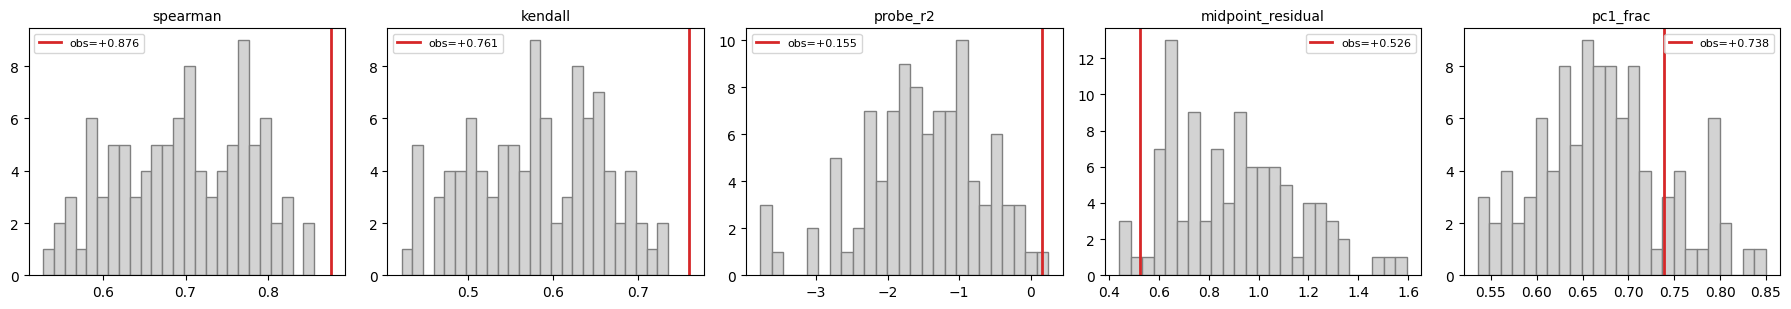

In [ ]:
N_PERM = 100
PERM_SEED = 13
_rng = np.random.default_rng(PERM_SEED)

flat_vecs = [v for lvl in levels_present for v in abl_13[lvl]]
sizes = [len(abl_13[lvl]) for lvl in levels_present]
null = {k: [] for k in metrics_13}
for _ in range(N_PERM):
    perm = _rng.permutation(len(flat_vecs))
    permuted = {}
    start = 0
    for lvl, sz in zip(levels_present, sizes):
        permuted[lvl] = [flat_vecs[perm[i]] for i in range(start, start + sz)]
        start += sz
    m = ordinal_linearity_metrics(permuted, levels_present)
    for k in null:
        null[k].append(m[k])
null = {k: np.array(v) for k, v in null.items()}

print(f'Label-permutation null (n={N_PERM}) vs. observed at layer {LAYER}:')
for k, obs in metrics_13.items():
    if np.isnan(obs):
        print(f'  {k:>20}: n/a')
        continue
    if k == 'midpoint_residual':
        p = float((null[k] <= obs).mean()); tail = '<='
    else:
        p = float((null[k] >= obs).mean()); tail = '>='
    print(f'  {k:>20}: obs={obs:+.4f}  null μ={null[k].mean():+.4f} σ={null[k].std():.4f}  '
          f'p(null{tail}obs)={p:.3f}')

fig, axes = plt.subplots(1, 5, figsize=(18, 3.2))
for ax, (k, obs) in zip(axes, metrics_13.items()):
    if np.isnan(obs):
        ax.set_title(f'{k}\n(n/a)'); ax.axis('off'); continue
    ax.hist(null[k], bins=25, color='lightgray', edgecolor='gray')
    ax.axvline(obs, color='C3', linewidth=2, label=f'obs={obs:+.3f}')
    ax.set_title(k, fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

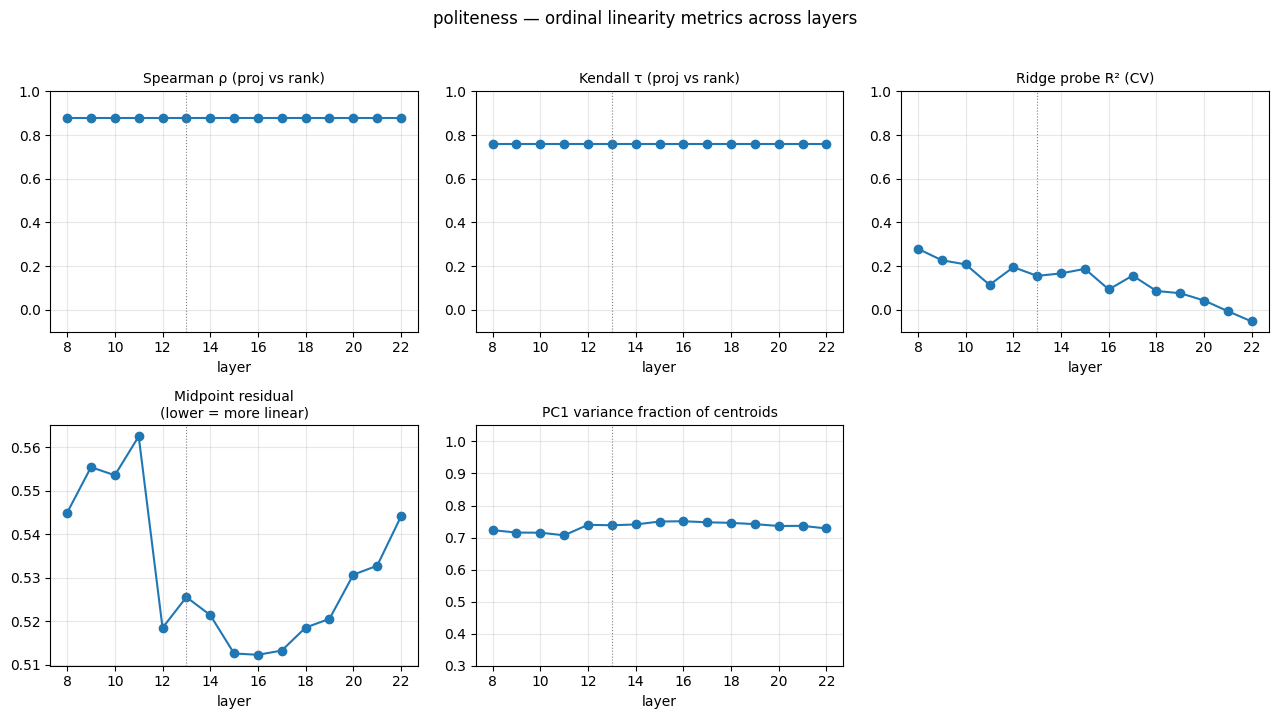

In [ ]:
sweep_results = {k: [] for k in metrics_13}
for layer in sweep_layers:
    acts_layer = {(t, i, s): v for (t, i, s, l), v in acts_all.items() if l == layer}
    abl = acts_by_level_from_dict(acts_layer, levels_present)
    m = ordinal_linearity_metrics(abl, levels_present)
    for k in sweep_results:
        sweep_results[k].append(m[k])

panel_info = [
    ('spearman', 'Spearman ρ (proj vs rank)', (-0.1, 1.0)),
    ('kendall', 'Kendall τ (proj vs rank)', (-0.1, 1.0)),
    ('probe_r2', 'Ridge probe R² (CV)', (-0.1, 1.0)),
    ('midpoint_residual', 'Midpoint residual\n(lower = more linear)', None),
    ('pc1_frac', 'PC1 variance fraction of centroids', (0.3, 1.05)),
]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (key, title, ylim) in zip(axes.flat, panel_info):
    ax.plot(sweep_layers, sweep_results[key], marker='o', linewidth=1.5)
    ax.axvline(LAYER, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlabel('layer')
    ax.set_title(title, fontsize=10)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(alpha=0.3)
axes.flat[5].axis('off')
fig.suptitle(f'{TRAIT} — ordinal linearity metrics across layers', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## SAE (sparse) representation experiments

**Hypothesis:** dense residual-stream activations represent the politeness ladder
more linearly than the sparse Gemma Scope SAE feature activations at the same site.

We use the **Gemma Scope 2b-pt-res canonical, width-16k JumpReLU SAEs**
(Lieberum et al., 2024; `google/gemma-scope-2b-pt-res`). For each layer we re-extract
per-token residuals, apply the layer-matched SAE encoder, and mean-pool the resulting
sparse codes over content tokens (matching how dense activations are pooled). The same
four ordinal-linearity metrics — Spearman ρ, Kendall τ, ridge probe R², centroid
midpoint residual, PC1 fraction — are then computed on the ~16k-dim sparse codes and
compared layer-by-layer against the dense baseline.

In [ ]:
# Requires sae-lens >= 5.0:  pip install sae-lens
from sae_lens import SAE


def load_gemma_scope_sae(layer: int, device: str, width: str = "16k"):
    """Load the canonical Gemma Scope residual-stream SAE for *layer*.

    Returns the SAE in eval mode on *device*. d_in matches gemma-2-2b's hidden_dim (2304).
    """
    sae = SAE.from_pretrained(
        release="gemma-scope-2b-pt-res-canonical",
        sae_id=f"layer_{layer}/width_{width}/canonical",
        device=device,
    )
    sae.eval()
    return sae


def encode_with_sae_one_layer(
    samples, model, tokenizer, layer, sae, device, batch_size=8,
):
    """Run *model* on *samples*, encode per-token residuals at *layer* through *sae*,
    and mean-pool the sparse codes over content tokens (BOS/EOS/pad excluded).

    Returns
    -------
    codes : dict[(trait, intensity, scenario_id), tensor]
        Mean-pooled SAE codes, shape (d_sae,).
    mean_l0 : float
        Average active features per content token (sparsity check).
    """
    special_ids = {
        tid for tid in (tokenizer.bos_token_id, tokenizer.eos_token_id, tokenizer.pad_token_id)
        if tid is not None
    }
    bucket = {}
    total_active = 0.0
    total_tokens = 0.0
    for start in range(0, len(samples), batch_size):
        batch = samples[start:start + batch_size]
        texts = [s.prompt for s in batch]
        enc = tokenizer(texts, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            out = model(**enc, output_hidden_states=True)
        resid = out.hidden_states[layer + 1]  # (B, L, D)

        token_ids = enc["input_ids"]
        attention_mask = enc["attention_mask"].bool()
        valid = attention_mask.clone()
        for sid in special_ids:
            valid &= token_ids != sid
        empty_rows = valid.sum(dim=1) == 0
        if empty_rows.any():
            valid[empty_rows] = attention_mask[empty_rows]
        weights = valid.to(resid.dtype).unsqueeze(-1)
        counts = weights.sum(dim=1).clamp(min=1)

        B, L, D = resid.shape
        with torch.no_grad():
            codes = sae.encode(resid.reshape(-1, D).to(sae.dtype))  # (B*L, F)
        codes = codes.reshape(B, L, -1).to(resid.dtype)

        active = (codes != 0).sum(dim=-1).float()  # (B, L)
        total_active += (active * valid.float()).sum().item()
        total_tokens += valid.sum().item()

        pooled = (codes * weights).sum(dim=1) / counts  # (B, F)
        pooled = pooled.detach().to("cpu", dtype=torch.float32)
        for i, sample in enumerate(batch):
            key = (sample.trait, sample.intensity, sample.scenario_id)
            bucket.setdefault(key, []).append(pooled[i])

    codes_dict = {k: torch.stack(v).mean(dim=0) for k, v in bucket.items()}
    mean_l0 = total_active / max(1.0, total_tokens)
    return codes_dict, mean_l0


SAE_WIDTH = "16k"

In [ ]:
sae_13 = load_gemma_scope_sae(LAYER, device, SAE_WIDTH)
print(f'Loaded SAE  layer={LAYER}  width={SAE_WIDTH}  d_in={sae_13.cfg.d_in}  d_sae={sae_13.cfg.d_sae}')

sae_acts_13, sae_l0_13 = encode_with_sae_one_layer(
    samples, model, tokenizer, LAYER, sae_13, device
)
sae_abl_13 = acts_by_level_from_dict(sae_acts_13, levels_present)
print(f'Mean per-token L0 (active features / token): {sae_l0_13:.1f}')

sae_metrics_13 = ordinal_linearity_metrics(sae_abl_13, levels_present)
print(f'\nLayer {LAYER} — SAE (sparse) linearity metrics:')
for k, v in sae_metrics_13.items():
    print(f'  {k:>20}: {v:+.4f}      (dense: {metrics_13[k]:+.4f})')

Loaded SAE  layer=13  width=16k  d_in=2304  d_sae=16384
Mean per-token L0 (active features / token): 80.0

Layer 13 — SAE (sparse) linearity metrics:
              spearman: +0.8762      (dense: +0.8762)
               kendall: +0.7612      (dense: +0.7612)
              probe_r2: +0.0081      (dense: +0.1551)
     midpoint_residual: +0.6310      (dense: +0.5256)
              pc1_frac: +0.6576      (dense: +0.7385)


SAE difference-vector cosine similarity matrix (layer 13, width 16k):
                                 politeness:high-mid         politeness:mid-low        politeness:high-low
      politeness:high-mid                     1.0000                    -0.3026                     0.6255
       politeness:mid-low                    -0.3026                     1.0000                     0.5342
      politeness:high-low                     0.6255                     0.5342                     1.0000


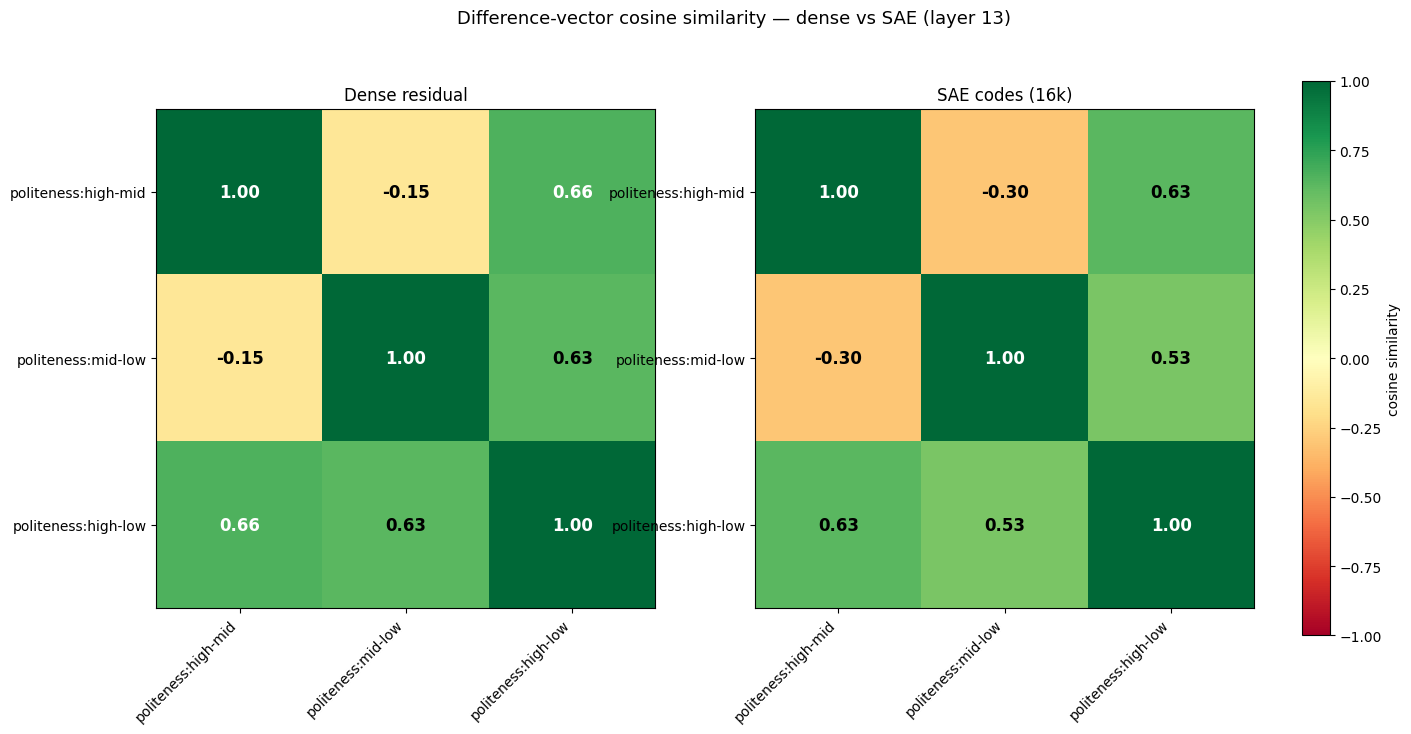

In [ ]:
sae_diffs_13 = compute_difference_vectors(sae_acts_13, TRAITS_CFG)
sae_labels, sae_matrix = similarity_matrix(sae_diffs_13)

print(f'SAE difference-vector cosine similarity matrix (layer {LAYER}, width {SAE_WIDTH}):')
header = f"{'':>25}" + "".join(f"{l:>27}" for l in sae_labels)
print(header)
for i, li in enumerate(sae_labels):
    row = f"{li:>25}" + "".join(f"{sae_matrix[i, j]:>27.4f}" for j in range(len(sae_labels)))
    print(row)

n = len(sae_labels)
cell = 2.4
fig, axes = plt.subplots(1, 2, figsize=(max(13, n * cell * 2 + 1), max(5, n * cell)))
for ax, mat, title in zip(axes, [matrix, sae_matrix], ['Dense residual', f'SAE codes ({SAE_WIDTH})']):
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap='RdYlGn')
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(sae_labels, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(sae_labels, fontsize=10)
    for i, j in itertools.product(range(n), range(n)):
        color = 'white' if abs(mat[i, j]) > 0.65 else 'black'
        ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center',
                fontsize=12, fontweight='bold', color=color)
    ax.set_title(title, fontsize=12)
fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.04, pad=0.04, label='cosine similarity')
fig.suptitle(f'Difference-vector cosine similarity — dense vs SAE (layer {LAYER})', fontsize=13)
plt.show()

SAE label-permutation null (n=100) vs. observed at layer 13:
              spearman: obs=+0.8762  null μ=+0.7165 σ=0.0702  p(null>=obs)=0.000
               kendall: obs=+0.7612  null μ=+0.5911 σ=0.0693  p(null>=obs)=0.000
              probe_r2: obs=+0.0081  null μ=-1.3515 σ=0.7000  p(null>=obs)=0.010
     midpoint_residual: obs=+0.6310  null μ=+0.8902 σ=0.2444  p(null<=obs)=0.150
              pc1_frac: obs=+0.6576  null μ=+0.6657 σ=0.0669  p(null>=obs)=0.510


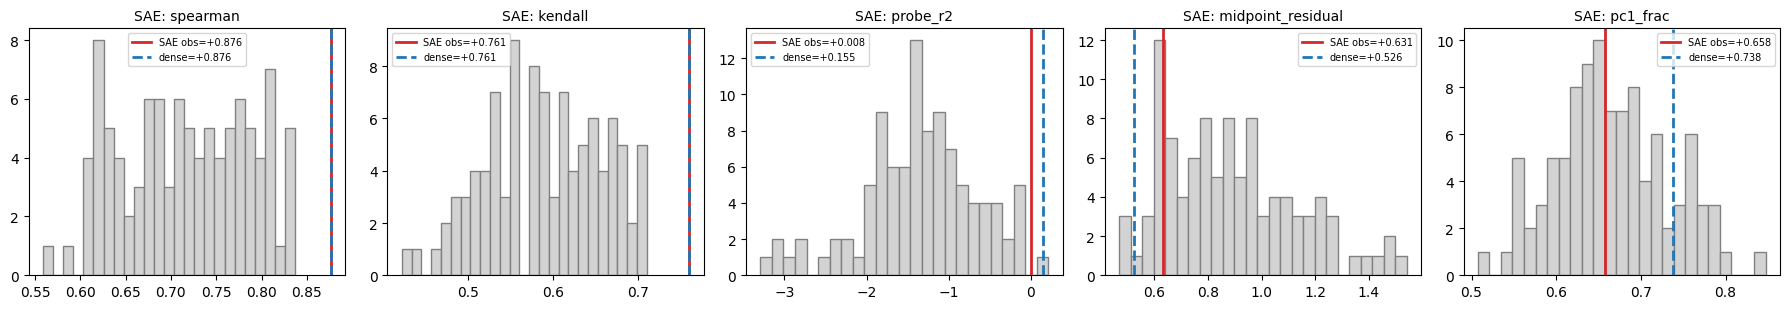

In [ ]:
sae_flat = [v for lvl in levels_present for v in sae_abl_13[lvl]]
sae_sizes = [len(sae_abl_13[lvl]) for lvl in levels_present]
sae_rng = np.random.default_rng(PERM_SEED)
sae_null = {k: [] for k in sae_metrics_13}
for _ in range(N_PERM):
    perm = sae_rng.permutation(len(sae_flat))
    permuted = {}
    start = 0
    for lvl, sz in zip(levels_present, sae_sizes):
        permuted[lvl] = [sae_flat[perm[i]] for i in range(start, start + sz)]
        start += sz
    m = ordinal_linearity_metrics(permuted, levels_present)
    for k in sae_null:
        sae_null[k].append(m[k])
sae_null = {k: np.array(v) for k, v in sae_null.items()}

print(f'SAE label-permutation null (n={N_PERM}) vs. observed at layer {LAYER}:')
for k, obs in sae_metrics_13.items():
    if np.isnan(obs):
        print(f'  {k:>20}: n/a'); continue
    if k == 'midpoint_residual':
        p = float((sae_null[k] <= obs).mean()); tail = '<='
    else:
        p = float((sae_null[k] >= obs).mean()); tail = '>='
    print(f'  {k:>20}: obs={obs:+.4f}  null μ={sae_null[k].mean():+.4f} σ={sae_null[k].std():.4f}  '
          f'p(null{tail}obs)={p:.3f}')

fig, axes = plt.subplots(1, 5, figsize=(18, 3.2))
for ax, (k, obs) in zip(axes, sae_metrics_13.items()):
    if np.isnan(obs):
        ax.set_title(f'{k}\n(n/a)'); ax.axis('off'); continue
    ax.hist(sae_null[k], bins=25, color='lightgray', edgecolor='gray')
    ax.axvline(obs, color='C3', linewidth=2, label=f'SAE obs={obs:+.3f}')
    ax.axvline(metrics_13[k], color='C0', linewidth=2, linestyle='--', label=f'dense={metrics_13[k]:+.3f}')
    ax.set_title(f'SAE: {k}', fontsize=10)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
sae_sweep_results = {k: [] for k in metrics_13}
sae_l0_per_layer = []
for layer in sweep_layers:
    sae = load_gemma_scope_sae(layer, device, SAE_WIDTH)
    sae_acts_layer, l0_layer = encode_with_sae_one_layer(
        samples, model, tokenizer, layer, sae, device
    )
    sae_abl_layer = acts_by_level_from_dict(sae_acts_layer, levels_present)
    m = ordinal_linearity_metrics(sae_abl_layer, levels_present)
    for k in sae_sweep_results:
        sae_sweep_results[k].append(m[k])
    sae_l0_per_layer.append(l0_layer)
    print(f'layer {layer:2d}  L0={l0_layer:5.1f}  ' +
          '  '.join(f'{k}={sae_sweep_results[k][-1]:+.3f}' for k in sae_sweep_results))
    del sae
    if device == 'cuda':
        torch.cuda.empty_cache()
    elif device == 'mps':
        torch.mps.empty_cache()

layer  8  L0= 70.2  spearman=+0.887  kendall=+0.774  probe_r2=-0.195  midpoint_residual=+0.649  pc1_frac=+0.642
layer  9  L0= 73.0  spearman=+0.887  kendall=+0.774  probe_r2=-0.086  midpoint_residual=+0.651  pc1_frac=+0.641
layer 10  L0= 76.8  spearman=+0.876  kendall=+0.761  probe_r2=-0.154  midpoint_residual=+0.644  pc1_frac=+0.644
layer 11  L0= 76.7  spearman=+0.866  kendall=+0.749  probe_r2=-0.429  midpoint_residual=+0.688  pc1_frac=+0.614
layer 12  L0= 78.9  spearman=+0.877  kendall=+0.761  probe_r2=+0.029  midpoint_residual=+0.584  pc1_frac=+0.688
layer 13  L0= 80.0  spearman=+0.876  kendall=+0.761  probe_r2=+0.008  midpoint_residual=+0.631  pc1_frac=+0.658
layer 14  L0= 80.2  spearman=+0.876  kendall=+0.761  probe_r2=-0.125  midpoint_residual=+0.607  pc1_frac=+0.674
layer 15  L0= 76.7  spearman=+0.876  kendall=+0.761  probe_r2=-0.151  midpoint_residual=+0.607  pc1_frac=+0.687
layer 16  L0= 79.0  spearman=+0.876  kendall=+0.761  probe_r2=-0.270  midpoint_residual=+0.610  pc1_frac

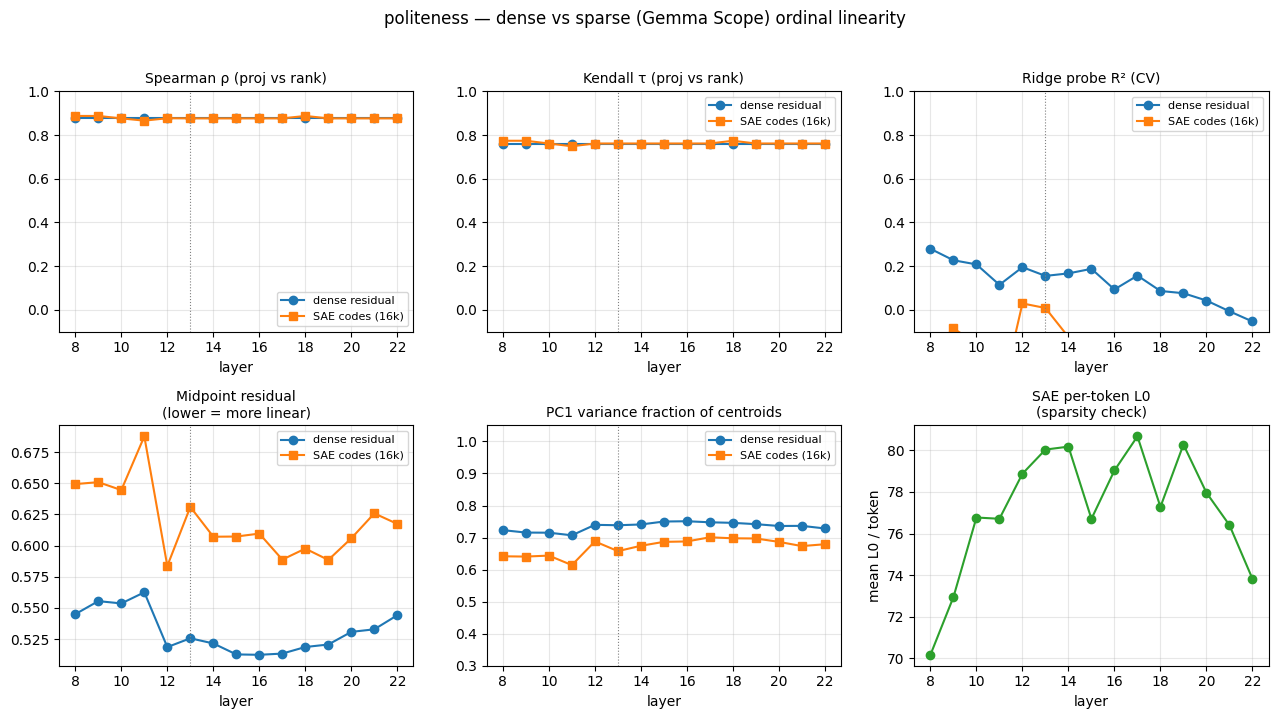

In [ ]:
panel_info_sae = [
    ('spearman', 'Spearman ρ (proj vs rank)', (-0.1, 1.0)),
    ('kendall', 'Kendall τ (proj vs rank)', (-0.1, 1.0)),
    ('probe_r2', 'Ridge probe R² (CV)', (-0.1, 1.0)),
    ('midpoint_residual', 'Midpoint residual\n(lower = more linear)', None),
    ('pc1_frac', 'PC1 variance fraction of centroids', (0.3, 1.05)),
]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (key, title, ylim) in zip(axes.flat, panel_info_sae):
    ax.plot(sweep_layers, sweep_results[key], marker='o', linewidth=1.5, label='dense residual')
    ax.plot(sweep_layers, sae_sweep_results[key], marker='s', linewidth=1.5, label=f'SAE codes ({SAE_WIDTH})')
    ax.axvline(LAYER, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlabel('layer')
    ax.set_title(title, fontsize=10)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes.flat[5].plot(sweep_layers, sae_l0_per_layer, marker='o', linewidth=1.5, color='C2')
axes.flat[5].set_xlabel('layer')
axes.flat[5].set_ylabel('mean L0 / token')
axes.flat[5].set_title('SAE per-token L0\n(sparsity check)', fontsize=10)
axes.flat[5].grid(alpha=0.3)
fig.suptitle(f'{TRAIT} — dense vs sparse (Gemma Scope) ordinal linearity', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()